## Conhecendo os dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dados = pd.read_csv('/content/drive/MyDrive/Dados_Csv/qualidade_leite.csv')
dados.head()

,pH,Temperatura,Sabor,Odor,Gordura,Turbidez,Cor,Qualidade
0,6.6,35,1,0,1,0,254,alta
1,6.6,36,0,1,0,1,253,alta
2,8.5,70,1,1,1,1,246,NaN
3,9.5,34,1,1,0,1,255,NaN
4,6.6,37,0,0,0,0,255,média


In [3]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pH           1059 non-null   float64
 1   Temperatura  1059 non-null   int64  
 2   Sabor        1059 non-null   int64  
 3   Odor         1059 non-null   int64  
 4   Gordura      1059 non-null   int64  
 5   Turbidez     1059 non-null   int64  
 6   Cor          1059 non-null   int64  
 7   Qualidade    424 non-null    object 
dtypes: float64(1), int64(6), object(1)
memory usage: 66.3+ KB


In [4]:
dados['Qualidade'].value_counts(dropna=False)

,count
Qualidade,
NaN,635
baixa,184
média,149
alta,91


In [5]:
# Proporção dos dados faltantes
dados['Qualidade'].isna().sum()/dados.shape[0]*100

np.float64(59.962228517469306)

In [6]:
dados['Sabor'].unique()

array([1, 0])

In [7]:
dados['Odor'].unique()

array([0, 1])

In [8]:
dados['Gordura'].unique()

array([1, 0])

In [9]:
dados['Turbidez'].unique()

array([0, 1])

In [10]:
dados['Cor'].unique()

array([254, 253, 246, 255, 250, 247, 245, 240, 248])

## Análise de Exploratória de Dados

### Distribuição do dados



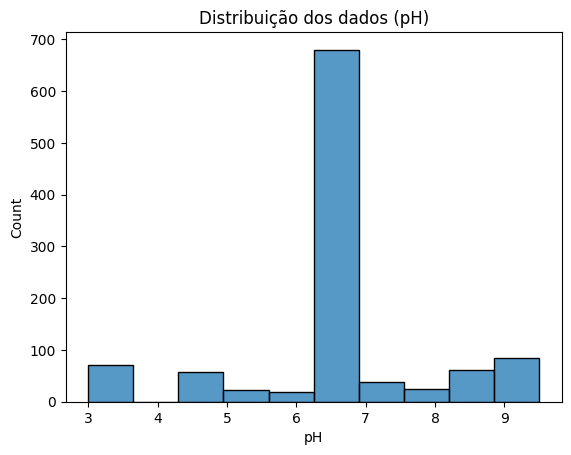

In [11]:
sns.histplot(x='pH', data=dados, bins=10)
plt.title('Distribuição dos dados (pH)')
plt.show()

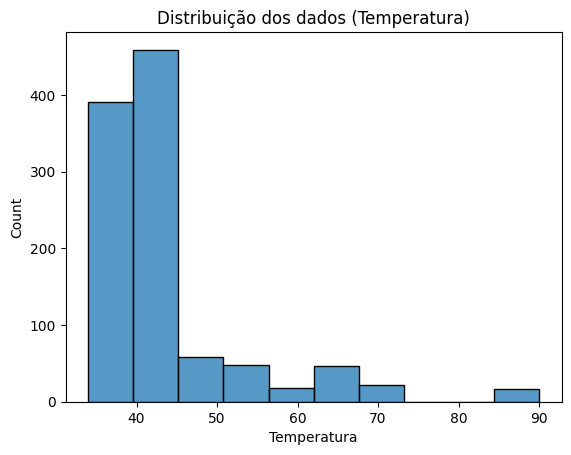

In [12]:
sns.histplot(x='Temperatura', data=dados, bins=10)
plt.title('Distribuição dos dados (Temperatura)')
plt.show()

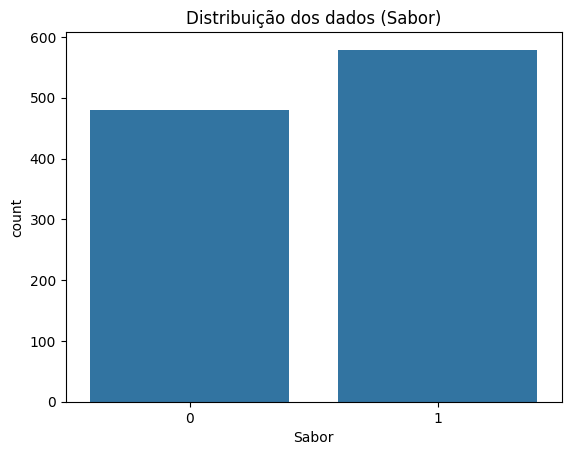

In [13]:
sns.countplot(x='Sabor', data=dados)
plt.title('Distribuição dos dados (Sabor)')
plt.show()

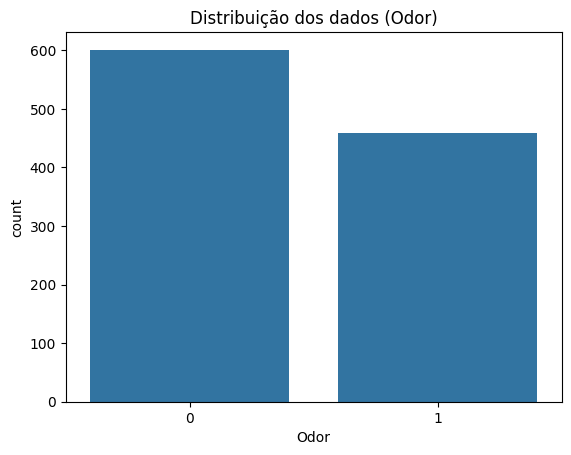

In [14]:
sns.countplot(x='Odor', data=dados)
plt.title('Distribuição dos dados (Odor)')
plt.show()

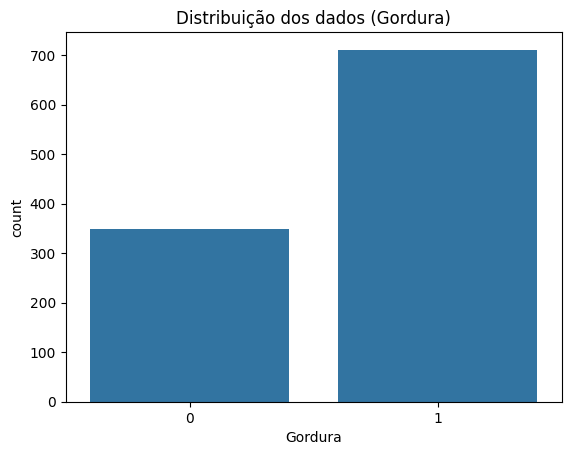

In [15]:
sns.countplot(x='Gordura', data=dados)
plt.title('Distribuição dos dados (Gordura)')
plt.show()

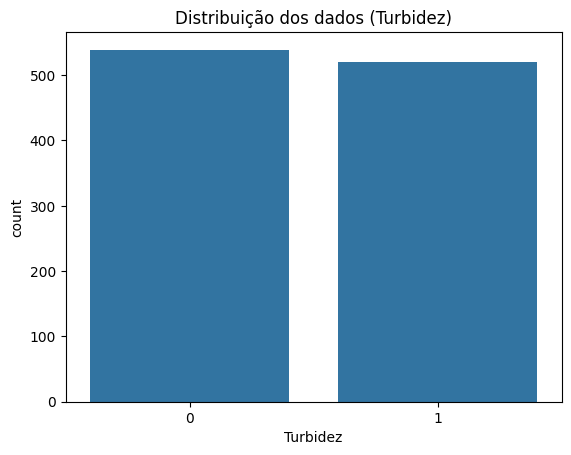

In [16]:
sns.countplot(x='Turbidez', data=dados)
plt.title('Distribuição dos dados (Turbidez)')
plt.show()

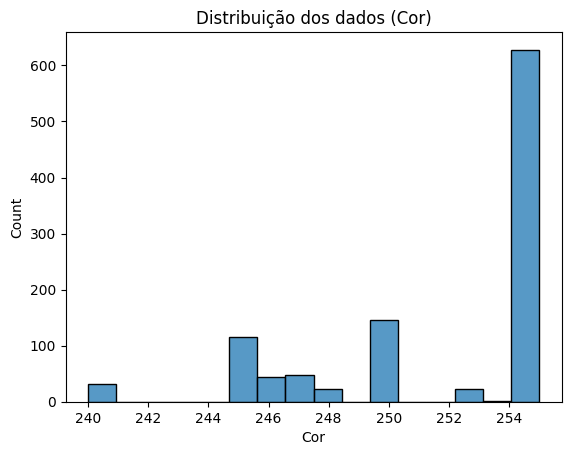

In [17]:
sns.histplot(x='Cor', data=dados)
plt.title('Distribuição dos dados (Cor)')
plt.show()

### Relação das variáveis com a variável alvo

In [18]:
qualidade_por_ph = dados.groupby('Qualidade')['pH'].mean().reset_index()
qualidade_por_ph

,Qualidade,pH
0,alta,6.708791
1,baixa,6.658152
2,média,6.632215


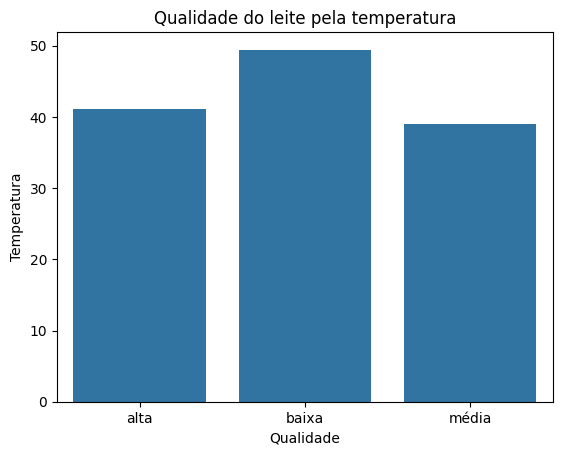

In [19]:
qualidade_por_temperatura = dados.groupby('Qualidade')['Temperatura'].mean().reset_index()
qualidade_por_temperatura

sns.barplot(x='Qualidade', y='Temperatura', data=qualidade_por_temperatura)
plt.title('Qualidade do leite pela temperatura')
plt.show()

In [20]:
dados.columns

Index(['pH', 'Temperatura', 'Sabor', 'Odor', 'Gordura', 'Turbidez', 'Cor',
       'Qualidade'],
      dtype='object')

In [21]:
# Tabela cruzada para ver os valores absolutos
ct = pd.crosstab(dados['Qualidade'], dados['Sabor'])
display(ct)

Sabor,0,1
Qualidade,,
alta,31,60
baixa,73,111
média,89,60


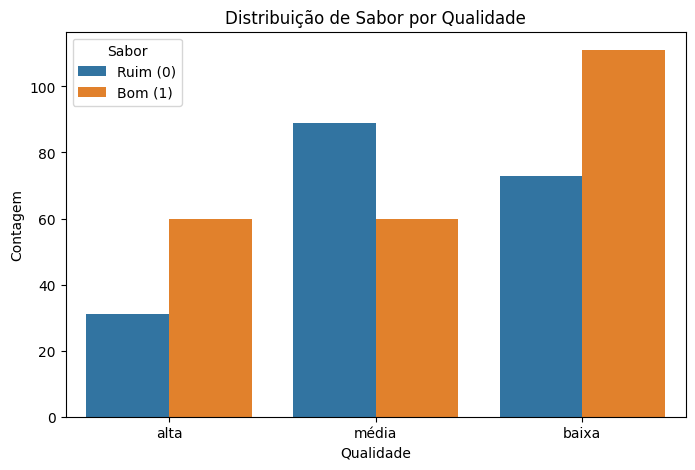

In [22]:
# Criando o gráfico para visualizar a relação entre Qualidade e Sabor
plt.figure(figsize=(8, 5))
sns.countplot(x='Qualidade', hue='Sabor', data=dados)
plt.title('Distribuição de Sabor por Qualidade')
plt.xlabel('Qualidade')
plt.ylabel('Contagem')
plt.legend(title='Sabor', labels=['Ruim (0)', 'Bom (1)'])
plt.show()

In [23]:
ct = pd.crosstab(dados['Qualidade'], dados['Odor'])
display(ct)

Odor,0,1
Qualidade,,
alta,23,68
baixa,98,86
média,132,17


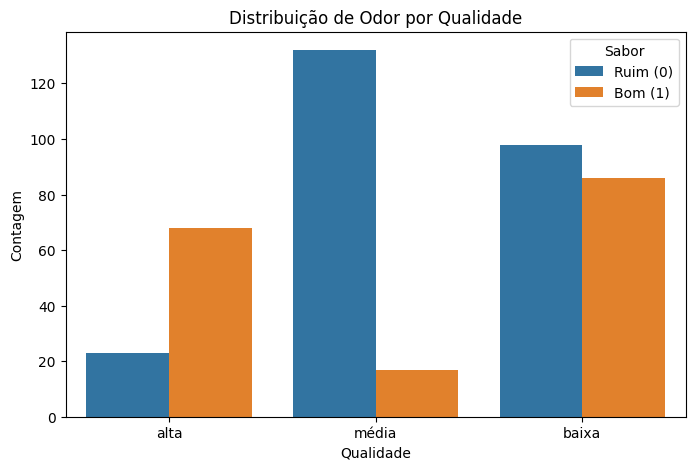

In [24]:
# Criando o gráfico para visualizar a relação entre Qualidade e Odor
plt.figure(figsize=(8, 5))
sns.countplot(x='Qualidade', hue='Odor', data=dados)
plt.title('Distribuição de Odor por Qualidade')
plt.xlabel('Qualidade')
plt.ylabel('Contagem')
plt.legend(title='Sabor', labels=['Ruim (0)', 'Bom (1)'])
plt.show()

In [25]:
ct = pd.crosstab(dados['Qualidade'], dados['Gordura'])
display(ct)

Gordura,0,1
Qualidade,,
alta,1,90
baixa,47,137
média,95,54


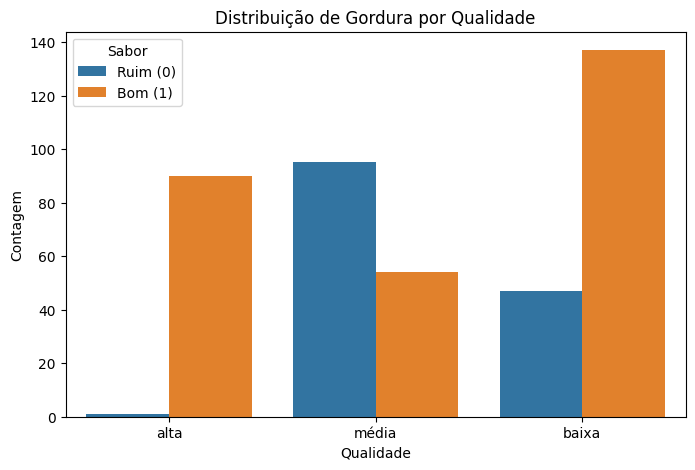

In [26]:
# Criando o gráfico para visualizar a relação entre Qualidade e Gordura
plt.figure(figsize=(8, 5))
sns.countplot(x='Qualidade', hue='Gordura', data=dados)
plt.title('Distribuição de Gordura por Qualidade')
plt.xlabel('Qualidade')
plt.ylabel('Contagem')
plt.legend(title='Sabor', labels=['Ruim (0)', 'Bom (1)'])
plt.show()

In [27]:
ct = pd.crosstab(dados['Qualidade'], dados['Turbidez'])
display(ct)

Turbidez,0,1
Qualidade,,
alta,39,52
baixa,48,136
média,128,21


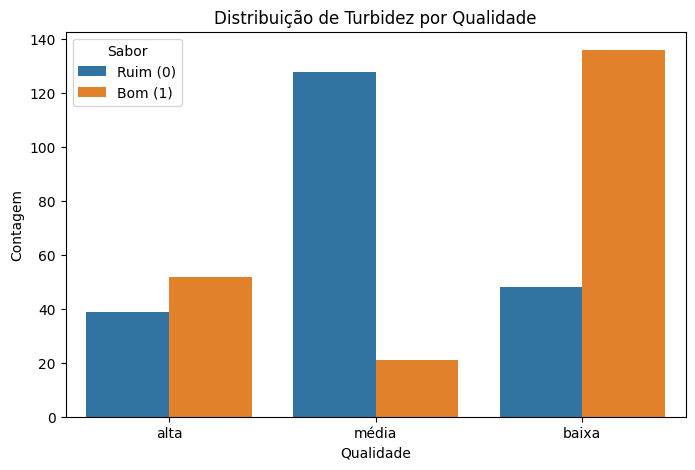

In [28]:
# Criando o gráfico para visualizar a relação entre Qualidade e Turbidez
plt.figure(figsize=(8, 5))
sns.countplot(x='Qualidade', hue='Turbidez', data=dados)
plt.title('Distribuição de Turbidez por Qualidade')
plt.xlabel('Qualidade')
plt.ylabel('Contagem')
plt.legend(title='Sabor', labels=['Ruim (0)', 'Bom (1)'])
plt.show()

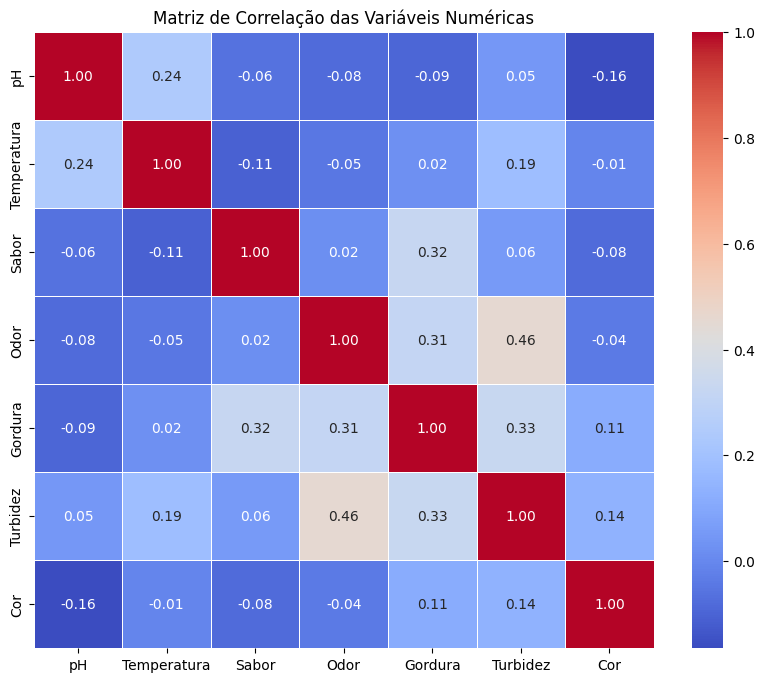

In [29]:
plt.figure(figsize=(10, 8))
correlation_matrix = dados.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

## Aprendizado supervisionado

### Selecionando dados rotulados

In [30]:
dados_rotulados = dados.dropna()

In [31]:
dados_rotulados

,pH,Temperatura,Sabor,Odor,Gordura,Turbidez,Cor,Qualidade
0,6.6,35,1,0,1,0,254,alta
1,6.6,36,0,1,0,1,253,alta
4,6.6,37,0,0,0,0,255,média
6,5.5,45,1,0,1,1,250,baixa
7,4.5,60,0,1,1,1,250,baixa
...,...,...,...,...,...,...,...,...
1047,6.8,45,1,1,1,0,245,alta
1048,9.5,34,1,1,0,1,255,baixa
1049,6.5,37,0,0,0,0,255,média
1052,6.5,40,1,0,0,0,250,média


In [32]:
x = dados_rotulados.drop('Qualidade', axis = 1)
y = dados_rotulados['Qualidade']

In [33]:
dados_rotulados['Qualidade'].value_counts(dropna=False)

,count
Qualidade,
baixa,184
média,149
alta,91


#### Preparando os dados

In [34]:
from sklearn.preprocessing import LabelEncoder

In [35]:
label_encoder = LabelEncoder()

In [36]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [37]:
label_encoder.inverse_transform([0, 1, 2])

array(['alta', 'baixa', 'média'], dtype=object)

In [38]:
from sklearn.preprocessing import MinMaxScaler

In [39]:
scaler = MinMaxScaler()
x_normalizado = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)
x_normalizado

,pH,Temperatura,Sabor,Odor,Gordura,Turbidez,Cor
0,0.553846,0.017857,1.0,0.0,1.0,0.0,0.933333
1,0.553846,0.035714,0.0,1.0,0.0,1.0,0.866667
2,0.553846,0.053571,0.0,0.0,0.0,0.0,1.000000
3,0.384615,0.196429,1.0,0.0,1.0,1.0,0.666667
4,0.230769,0.464286,0.0,1.0,1.0,1.0,0.666667
...,...,...,...,...,...,...,...
419,0.584615,0.196429,1.0,1.0,1.0,0.0,0.333333
420,1.000000,0.000000,1.0,1.0,0.0,1.0,1.000000
421,0.538462,0.053571,0.0,0.0,0.0,0.0,1.000000
422,0.538462,0.107143,1.0,0.0,0.0,0.0,0.666667


### Criando Modelo Supervisionado

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x_normalizado, y, stratify = y, random_state = 10)

In [42]:
from sklearn.svm import SVC

In [43]:
svm = SVC(kernel = 'linear', random_state = 10)
svm.fit(x_treino, y_treino)

SVC(kernel='linear', random_state=10)

In [44]:
from sklearn.metrics import classification_report

In [45]:
y_previsto = svm.predict(x_teste)
resultados_svm = classification_report(y_teste, y_previsto)
print(resultados_svm)

              precision    recall  f1-score   support

           0       0.75      0.39      0.51        23
           1       0.67      0.91      0.77        46
           2       0.90      0.76      0.82        37

    accuracy                           0.75       106
   macro avg       0.77      0.69      0.70       106
weighted avg       0.77      0.75      0.73       106



## Aprendizado semi-supervisionado

### Fazendo previsões

In [46]:
dados[dados['Qualidade'].isna()]

,pH,Temperatura,Sabor,Odor,Gordura,Turbidez,Cor,Qualidade
2,8.5,70,1,1,1,1,246,NaN
3,9.5,34,1,1,0,1,255,NaN
5,6.6,37,1,1,1,1,255,NaN
8,8.1,66,1,0,1,1,255,NaN
10,6.7,45,1,1,1,0,245,NaN
...,...,...,...,...,...,...,...,...
1053,8.1,66,1,0,1,1,255,NaN
1054,6.7,45,1,1,0,0,247,NaN
1055,6.7,38,1,0,1,0,255,NaN
1056,3.0,40,1,1,1,1,255,NaN


In [47]:
dados_sem_rotulos = dados[dados['Qualidade'].isna()].drop(columns = 'Qualidade')
dados_sem_rotulos.head()

,pH,Temperatura,Sabor,Odor,Gordura,Turbidez,Cor
2,8.5,70,1,1,1,1,246
3,9.5,34,1,1,0,1,255
5,6.6,37,1,1,1,1,255
8,8.1,66,1,0,1,1,255
10,6.7,45,1,1,1,0,245


In [48]:
dados_sem_rotulos_normalizados = pd.DataFrame(scaler.transform(dados_sem_rotulos), columns=dados_sem_rotulos.columns)
dados_sem_rotulos_normalizados

,pH,Temperatura,Sabor,Odor,Gordura,Turbidez,Cor
0,0.846154,0.642857,1.0,1.0,1.0,1.0,0.400000
1,1.000000,0.000000,1.0,1.0,0.0,1.0,1.000000
2,0.553846,0.053571,1.0,1.0,1.0,1.0,1.000000
3,0.784615,0.571429,1.0,0.0,1.0,1.0,1.000000
4,0.569231,0.196429,1.0,1.0,1.0,0.0,0.333333
...,...,...,...,...,...,...,...
630,0.784615,0.571429,1.0,0.0,1.0,1.0,1.000000
631,0.569231,0.196429,1.0,1.0,0.0,0.0,0.466667
632,0.569231,0.071429,1.0,0.0,1.0,0.0,1.000000
633,0.000000,0.107143,1.0,1.0,1.0,1.0,1.000000


In [49]:
y_previsto = svm.predict(dados_sem_rotulos_normalizados)

In [50]:
y_previsto

array([1, 1, 1, 1, 0, 1, 1, 1, 2, 0, 1, 2, 1, 1, 1, 0, 2, 2, 0, 1, 1, 1,
       2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 0, 1, 2, 1, 1, 2, 0, 1, 2, 0, 1,
       2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 2, 1, 2, 1, 2,
       2, 1, 1, 1, 2, 1, 1, 0, 1, 2, 0, 2, 1, 1, 2, 2, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 0, 1, 1, 1, 2, 0, 1, 1, 2, 2, 1, 1, 1, 2, 2, 1, 2, 1, 1,
       0, 1, 2, 0, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 2, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 2, 1, 0, 1, 1, 1, 1, 1, 2, 0, 1,
       2, 1, 2, 2, 1, 0, 1, 2, 1, 1, 1, 0, 2, 1, 2, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 2, 0, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 0, 1,
       2, 0, 1, 1, 1, 2, 0, 1, 1, 2, 1, 1, 1, 1, 0, 1, 2, 1, 1, 0, 2, 1,
       2, 0, 1, 0, 1, 2, 2, 2, 0, 1, 1, 1, 2, 0, 1, 2, 1, 2, 1, 2, 1, 1,
       2, 1, 2, 2, 1, 2, 1, 1, 1, 2, 0, 1, 2, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 2, 0, 1, 1, 2, 1, 2, 2, 1, 1, 0, 1, 1, 1, 2, 0, 1,
       2, 2, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 2, 0,

### Pseudo Labeling

In [51]:
novo_x_treino = pd.concat([x_treino, dados_sem_rotulos_normalizados], ignore_index=True)
novo_x_treino

,pH,Temperatura,Sabor,Odor,Gordura,Turbidez,Cor
0,0.584615,0.017857,1.0,0.0,1.0,0.0,0.400000
1,0.538462,0.035714,0.0,0.0,0.0,0.0,0.466667
2,0.538462,0.017857,1.0,0.0,1.0,0.0,0.400000
3,0.569231,0.071429,1.0,0.0,1.0,0.0,1.000000
4,0.553846,0.196429,0.0,1.0,1.0,1.0,0.666667
...,...,...,...,...,...,...,...
948,0.784615,0.571429,1.0,0.0,1.0,1.0,1.000000
949,0.569231,0.196429,1.0,1.0,0.0,0.0,0.466667
950,0.569231,0.071429,1.0,0.0,1.0,0.0,1.000000
951,0.000000,0.107143,1.0,1.0,1.0,1.0,1.000000


In [52]:
novo_y_treino = pd.concat([pd.Series(y_treino), pd.Series(y_previsto)], ignore_index=True)
novo_y_treino

,0
0,2
1,2
2,2
3,0
4,0
...,...
948,1
949,1
950,0
951,1


In [53]:
pseudo_labeling = SVC(kernel = 'linear', random_state=10)
pseudo_labeling.fit(novo_x_treino, novo_y_treino)

SVC(kernel='linear', random_state=10)

In [54]:
novo_y_previsto = pseudo_labeling.predict(x_teste)
resultados_pseudo_labeling = classification_report(y_teste, novo_y_previsto)

In [55]:
print('SVM Supervisionado')
print(resultados_svm)
print('-'*55)
print('SVM Pseudo Labeling')
print(resultados_pseudo_labeling)

SVM Supervisionado
              precision    recall  f1-score   support

           0       0.75      0.39      0.51        23
           1       0.67      0.91      0.77        46
           2       0.90      0.76      0.82        37

    accuracy                           0.75       106
   macro avg       0.77      0.69      0.70       106
weighted avg       0.77      0.75      0.73       106

-------------------------------------------------------
SVM Pseudo Labeling
              precision    recall  f1-score   support

           0       0.69      0.39      0.50        23
           1       0.66      0.87      0.75        46
           2       0.88      0.76      0.81        37

    accuracy                           0.73       106
   macro avg       0.74      0.67      0.69       106
weighted avg       0.74      0.73      0.72       106



## Self Training

### Tabela de probabilidade

In [56]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x_normalizado, y, stratify = y, random_state = 10)

In [57]:
svm = SVC(kernel = 'linear', probability = True, random_state = 10)
svm.fit(x_treino, y_treino)

SVC(kernel='linear', probability=True, random_state=10)

In [58]:
probabilidades = svm.predict_proba(dados_sem_rotulos_normalizados)
y_previsto = svm.predict(dados_sem_rotulos_normalizados)

In [59]:
tabela_resultados = pd.DataFrame(probabilidades, columns = ['Prob C0', 'Prob C1', 'Prob C2'])
tabela_resultados['Previsão'] = y_previsto
tabela_resultados['Probabilidade máxima'] = tabela_resultados[['Prob C0', 'Prob C1', 'Prob C2']].max(axis = 1)
tabela_resultados

,Prob C0,Prob C1,Prob C2,Previsão,Probabilidade máxima
0,0.147210,0.852259,0.000531,1,0.852259
1,0.249874,0.715117,0.035009,1,0.715117
2,0.491701,0.506534,0.001764,1,0.506534
3,0.076294,0.922552,0.001155,1,0.922552
4,0.693914,0.215723,0.090363,0,0.693914
...,...,...,...,...,...
630,0.076294,0.922552,0.001155,1,0.922552
631,0.130915,0.459888,0.409197,1,0.459888
632,0.540366,0.195320,0.264314,0,0.540366
633,0.255691,0.743873,0.000436,1,0.743873


### Selecionando rótulos com maior confiança

Text(0.5, 0, 'Probabilidade Máxima')

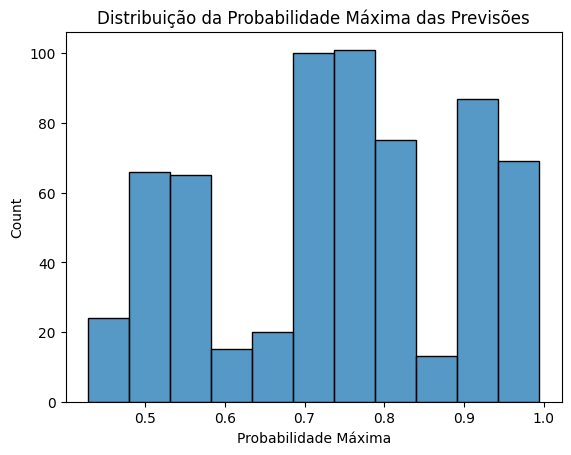

In [60]:
sns.histplot(x='Probabilidade máxima', data=tabela_resultados)
plt.title('Distribuição da Probabilidade Máxima das Previsões')
plt.xlabel('Probabilidade Máxima')

In [61]:
tabela_resultados['Probabilidade máxima'] > 0.75

,Probabilidade máxima
0,True
1,False
2,False
3,True
4,False
...,...
630,True
631,False
632,False
633,False


In [62]:
filtro_confianca = tabela_resultados['Probabilidade máxima'] > 0.75
novo_x_treino = pd.concat([x_treino, dados_sem_rotulos_normalizados[filtro_confianca]])
novo_y_treino = pd.concat([pd.Series(y_treino), tabela_resultados.loc[filtro_confianca, 'Previsão']])

### Modelo aprimorado

In [63]:
svm = SVC(kernel= 'linear', probability=True, random_state=10)
svm.fit(novo_x_treino, novo_y_treino)

SVC(kernel='linear', probability=True, random_state=10)

In [64]:
novo_y_previsto = svm.predict(x_teste)
resultados_self_training1 = classification_report(y_teste, novo_y_previsto)

In [65]:
print('SVM Supervisionado')
print(resultados_svm)
print('-'*55)
print('SVM Self Training 1º estágio')
print(resultados_self_training1)

SVM Supervisionado
              precision    recall  f1-score   support

           0       0.75      0.39      0.51        23
           1       0.67      0.91      0.77        46
           2       0.90      0.76      0.82        37

    accuracy                           0.75       106
   macro avg       0.77      0.69      0.70       106
weighted avg       0.77      0.75      0.73       106

-------------------------------------------------------
SVM Self Training 1º estágio
              precision    recall  f1-score   support

           0       0.75      0.39      0.51        23
           1       0.72      0.91      0.81        46
           2       0.92      0.89      0.90        37

    accuracy                           0.79       106
   macro avg       0.80      0.73      0.74       106
weighted avg       0.80      0.79      0.78       106



### Modelo Self Training

In [66]:
from sklearn.semi_supervised import SelfTrainingClassifier

In [67]:
pd.Series([-1]*dados_sem_rotulos_normalizados.shape[0])

,0
0,-1
1,-1
2,-1
3,-1
4,-1
...,...
630,-1
631,-1
632,-1
633,-1


In [68]:
x_treino_self_training = pd.concat([x_treino, dados_sem_rotulos_normalizados], ignore_index = True)
y_treino_self_training = pd.concat([pd.Series(y_treino), pd.Series([-1]*dados_sem_rotulos_normalizados.shape[0])], ignore_index = True)

In [69]:
x_treino_self_training

,pH,Temperatura,Sabor,Odor,Gordura,Turbidez,Cor
0,0.584615,0.017857,1.0,0.0,1.0,0.0,0.400000
1,0.538462,0.035714,0.0,0.0,0.0,0.0,0.466667
2,0.538462,0.017857,1.0,0.0,1.0,0.0,0.400000
3,0.569231,0.071429,1.0,0.0,1.0,0.0,1.000000
4,0.553846,0.196429,0.0,1.0,1.0,1.0,0.666667
...,...,...,...,...,...,...,...
948,0.784615,0.571429,1.0,0.0,1.0,1.0,1.000000
949,0.569231,0.196429,1.0,1.0,0.0,0.0,0.466667
950,0.569231,0.071429,1.0,0.0,1.0,0.0,1.000000
951,0.000000,0.107143,1.0,1.0,1.0,1.0,1.000000


In [70]:
y_treino_self_training

,0
0,2
1,2
2,2
3,0
4,0
...,...
948,-1
949,-1
950,-1
951,-1


In [71]:
svm = SVC(kernel = 'linear', probability= True, random_state = 10)

In [72]:
svm = SVC(kernel = 'linear', probability= True, random_state = 10)
self_training = SelfTrainingClassifier(svm, threshold = 0.80, max_iter = 15, verbose = True)

In [73]:
self_training.fit(x_treino_self_training, y_treino_self_training)

End of iteration 1, added 244 new labels.
End of iteration 2, added 105 new labels.
End of iteration 3, added 50 new labels.
End of iteration 4, added 3 new labels.
End of iteration 5, added 14 new labels.


SelfTrainingClassifier(estimator=SVC(kernel='linear', probability=True,
                                     random_state=10),
                       max_iter=15, threshold=0.8, verbose=True)

In [74]:
y_previsto = self_training.predict(x_teste)
resultados_self_training = classification_report(y_teste, y_previsto)

In [75]:
print('SVM Supervisionado')
print(resultados_svm)
print('-'*55)
print('SVM Self Training 1º estágio')
print(resultados_self_training1)
print('-'*55)
print('SVM Self Training')
print(resultados_self_training)

SVM Supervisionado
              precision    recall  f1-score   support

           0       0.75      0.39      0.51        23
           1       0.67      0.91      0.77        46
           2       0.90      0.76      0.82        37

    accuracy                           0.75       106
   macro avg       0.77      0.69      0.70       106
weighted avg       0.77      0.75      0.73       106

-------------------------------------------------------
SVM Self Training 1º estágio
              precision    recall  f1-score   support

           0       0.75      0.39      0.51        23
           1       0.72      0.91      0.81        46
           2       0.92      0.89      0.90        37

    accuracy                           0.79       106
   macro avg       0.80      0.73      0.74       106
weighted avg       0.80      0.79      0.78       106

-------------------------------------------------------
SVM Self Training
              precision    recall  f1-score   support

     

## Concluindo Projeto

### Label Propagation

In [76]:
from sklearn.semi_supervised import LabelPropagation

In [77]:
label_propagation = LabelPropagation()

In [78]:
label_propagation.fit(x_treino_self_training, y_treino_self_training)

LabelPropagation()

In [79]:
y_previsto = label_propagation.predict(x_teste)
resultados_label_propagation = classification_report(y_teste, y_previsto)

In [80]:
print('SVM Self Training')
print(resultados_self_training)
print('-'*50)
print('Label Propagation')
print(resultados_label_propagation)

SVM Self Training
              precision    recall  f1-score   support

           0       0.83      0.65      0.73        23
           1       0.81      0.91      0.86        46
           2       0.92      0.89      0.90        37

    accuracy                           0.85       106
   macro avg       0.85      0.82      0.83       106
weighted avg       0.85      0.85      0.85       106

--------------------------------------------------
Label Propagation
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        23
           1       1.00      0.89      0.94        46
           2       0.88      0.95      0.91        37

    accuracy                           0.93       106
   macro avg       0.93      0.95      0.94       106
weighted avg       0.94      0.93      0.93       106



### Armazenando o melhor modelo

In [83]:
import pickle
with open('min_max_scaler.pkl', 'wb') as arquivo:
    pickle.dump(scaler, arquivo)

with open('modelo_label_propagation.pkl', 'wb') as arquivo:
    pickle.dump(label_propagation, arquivo)

In [84]:
modelo_min_max = pd.read_pickle('/content/min_max_scaler.pkl')
modelo_label_propagation = pd.read_pickle('/content/modelo_label_propagation.pkl')

In [89]:
x_teste.columns

Index(['pH', 'Temperatura', 'Sabor', 'Odor', 'Gordura', 'Turbidez', 'Cor'], dtype='object')

In [85]:
novo_dado = {
    'pH':[6.4],
    'Temperatura':[52],
    'Sabor':[0],
    'Odor':[1],
    'Gordura':[1],
    'Turbidez':[0],
    'Cor':[253]
}

In [87]:
novo_dado = pd.DataFrame(novo_dado)
novo_dado = modelo_min_max.transform(novo_dado)

In [88]:
modelo_label_propagation.predict(novo_dado)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LabelPropagation was fitted with feature names
  warnings.warn(


array([0])

In [90]:
label_encoder.inverse_transform([0])

array(['alta'], dtype=object)